# 03 · Poisson Dağılımı
**Probability Lab** · Discrete Distributions

---
> **Bu notebook'ta ne öğreneceğiz?**  
> **Poisson dağılımını** sıfırdan anlayacağız — belirli bir zaman ya da alan içinde  
> kaç kez bir olayın gerçekleşeceğini modelleyen en güçlü araç.  
> Web trafiği, çağrı merkezleri, arızalar, tıbbi vakalar... hepsinde Poisson var.

**Önkoşul:** Bernoulli ve Binomial dağılımları (Notebook 02)  
**Kullanılan araçlar:** Python (scipy, matplotlib, seaborn), R (base), SQL (DuckDB)

---
## 1 · Sezgi: "Belirli bir sürede kaç kez olur?"

Bazı olaylar **belirli bir sürede veya alanda** tekrar tekrar gerçekleşebilir:

| Olay | Zaman/Alan birimi | λ (ortalama) |
|---|---|---|
| Bir web sitesine istek gelme | Dakika başına | Örn. 120 istek/dk |
| Çağrı merkezine telefon | Saat başına | Örn. 40 çağrı/saat |
| Fabrikada arıza | Hafta başına | Örn. 2.5 arıza/hafta |
| Bir sayfadaki yazım hatası | Sayfa başına | Örn. 0.3 hata/sayfa |
| Ağa gelen paket | Saniye başına | Örn. 1000 paket/sn |

Binomial bu sorular için de kullanılabilir — ama çok elverişsiz:  
"120 dakikada 7200 kez rastgele seç, her birinde $p$ ihtimalle istek gelsin" demek gülünç.  
Poisson bu sınır durumunun daha temiz halidir.

### Poisson'ın 3 Varsayımı

1. **Bağımsızlık:** Bir olayın gerçekleşmesi, diğerinin olasılığını etkilemez
2. **Homojenlik:** Olaylar zaman/alan içinde eşit yoğunlukla dağılmış
3. **Tekil oluş:** Aynı anda iki olay gerçekleşemez (dt → 0 limitinde)

> **Sezgi:** Trafiksiz bir yolda araba geçişleri bu koşulları genelde sağlar.  
> Rush hour trafiği veya sosyal ağ etkisi sağlamaz.

---
## 2 · Tanım ve PMF

### Tanım

$X \sim \text{Poisson}(\lambda)$ demek:
- Birim zaman/alanda ortalama $\lambda$ olay gerçekleşiyor
- $X$ = o birimde gözlemlenen olay sayısı
- $X \in \{0, 1, 2, 3, \ldots\}$ — üst sınır yok!

### PMF

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \ldots$$

Formülün üç parçası:

| Parça | Ne anlama geliyor? |
|---|---|
| $e^{-\lambda}$ | Sıfır olay gerçekleşme olasılığının temel faktörü |
| $\lambda^k$ | $k$ olayın ortalama oranına göre gerçekleşmesi |
| $k!$ | $k$ olayın sırasının önemi olmadığı için düzeltme |

### Beklenti ve Varyans

$$E[X] = \lambda$$
$$\text{Var}(X) = \lambda$$

**Dikkat:** Beklenti ve varyans eşit! Bu Poisson'ın karakteristik özelliğidir.  
Gerçek veride $\text{Var}(X) \gg E[X]$ ise **aşırı dağılma (overdispersion)** var → Poisson uygun değil.

### Sayısal Örnek

Bir web sitesine dakikada ortalama $\lambda = 4$ istek geliyor.

| $k$ | $P(X=k)$ | Hesap |
|---|---|---|
| 0 | $e^{-4} \cdot 1 / 1$ | 0.0183 |
| 1 | $e^{-4} \cdot 4 / 1$ | 0.0733 |
| 2 | $e^{-4} \cdot 16 / 2$ | 0.1465 |
| 4 | $e^{-4} \cdot 256 / 24$ | 0.1954 ← tepe |
| 10 | $e^{-4} \cdot 4^{10} / 10!$ | 0.0053 |

---
## 3 · Binomial ile İlişki: Poisson Limit Teoremi

**Poisson dağılımı, Binomial'ın özel bir limitidir:**

$$\text{Binomial}(n, p) \xrightarrow{n \to \infty, \; p \to 0, \; np = \lambda} \text{Poisson}(\lambda)$$

Yani:
- $n$ çok büyük (çok sayıda deneme)
- $p$ çok küçük (her denemede olay oldukça nadir)
- $np = \lambda$ sabit

> **Pratik kural:** $n \geq 20$ ve $p \leq 0.05$ ise Binomial yerine Poisson kullanabilirsin.

**Neden önemli?**  
- Binomial($10^6$, $10^{-6}$) hesaplamak çok ağır → Poisson(1) ile yaklaş
- Nadir olayların modellenmesinde Poisson doğal tercih

### Poisson Süreci

Poisson dağılımı bir **süreç** olarak da düşünülebilir:  
Olaylar arasındaki bekleme süreleri **Üstel dağılım** izler:

$$T \sim \text{Exp}(\lambda) \implies E[T] = \frac{1}{\lambda}$$

Dakikada $\lambda = 4$ istek geliyorsa, iki istek arası ortalama bekleme $1/4 = 0.25$ dakika.

Bu bağlantı: *sürekli zaman → kesikli sayım* köprüsüdür —  
gelecek bölümde sürekli dağılımlar işlenirken tekrar göreceğiz.

---
## 4 · Zaman Ölçeği Değiştirme

$\lambda$ **birime bağlıdır** — dikkat!

| Birim | $\lambda$ |
|---|---|
| Dakika başına 4 istek | $\lambda = 4$ |
| Saat başına aynı sistem | $\lambda = 240$ |
| 15 saniyede | $\lambda = 1$ |

**Kural:** $t$ zaman biriminde ortalama $\lambda \cdot t$ olay.

$$X_t \sim \text{Poisson}(\lambda t)$$

Örnek: Dakikada 4 istek geliyor. 30 dakikada kaç istek?  
$X_{30} \sim \text{Poisson}(4 \times 30) = \text{Poisson}(120)$

---
## 5 · Özet ve Karşılaştırma

| | Binomial | Poisson |
|---|---|---|
| Parametre | $n, p$ | $\lambda$ |
| Değer aralığı | $\{0, \ldots, n\}$ | $\{0, 1, 2, \ldots\}$ |
| $E[X]$ | $np$ | $\lambda$ |
| $\text{Var}(X)$ | $np(1-p)$ | $\lambda$ |
| Senaryo | Sabit $n$ deneme | Sürekli zaman/alan |
| Limit ilişkisi | — | $n \to \infty, p \to 0, np=\lambda$ |

**Ne zaman Poisson?**
- Sayım verisi (count data): 0, 1, 2, 3, ...
- Olay sayısının üst sınırı yok
- Nadir olaylar ($p$ küçük)
- Zaman veya alan bazlı oran biliniyorsa

**Ne zaman Poisson UYGUN DEĞİL?**
- $\text{Var}(X) > E[X]$ → Negatif Binom kullan
- Olaylar birbirini tetikliyor (salgın, viral yayılım) → başka modeller
- Sıfır sayım fazla → Zero-inflated Poisson

---
# 🐍 Python Uygulaması

5 adımda:
1. **Poisson PMF** — $\lambda$ değişince şekil nasıl değişiyor?
2. **Poisson CDF** — olasılık soruları
3. **Binomial vs Poisson** — Bike sharing saatlik kiralama sayısı
4. **Poisson süreci simülasyonu** — gelişler arası süre (Üstel)
5. **Gerçek veri** — NYC Services Request verisi 

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['font.size'] = 12
print('Hazir ✓')


Hazir ✓


---
### 📊 Python 1 — Poisson PMF: λ Değişince Ne Olur?

**Ne yapıyoruz?**  
Farklı $\lambda$ değerleri için Poisson PMF'ini görselleştiriyoruz.

**Mantık:**
- `stats.poisson(mu=lam)` → Poisson dağılım nesnesi  
  Not: scipy'da parametre adı `mu`, matematiksel `λ` ile aynıdır
- `.pmf(k)` → $P(X=k) = e^{-\lambda}\lambda^k / k!$
- `.mean()` ve `.var()` → ikisi de $\lambda$'ya eşit olmalı

**Gözlemlenecekler:**
- Küçük $\lambda$: sağa çarpık (sol tarafa yığılmış)
- Büyük $\lambda$: Normal'e benziyor (CLT etkisi)
- Tepe noktası: $\lfloor \lambda \rfloor$ veya $\lceil \lambda \rceil$ civarında

Manuel : e^(-4) * 4^2 / 2! = 0.146525
SciPy  : stats.poisson.pmf(2, mu=4) = 0.146525



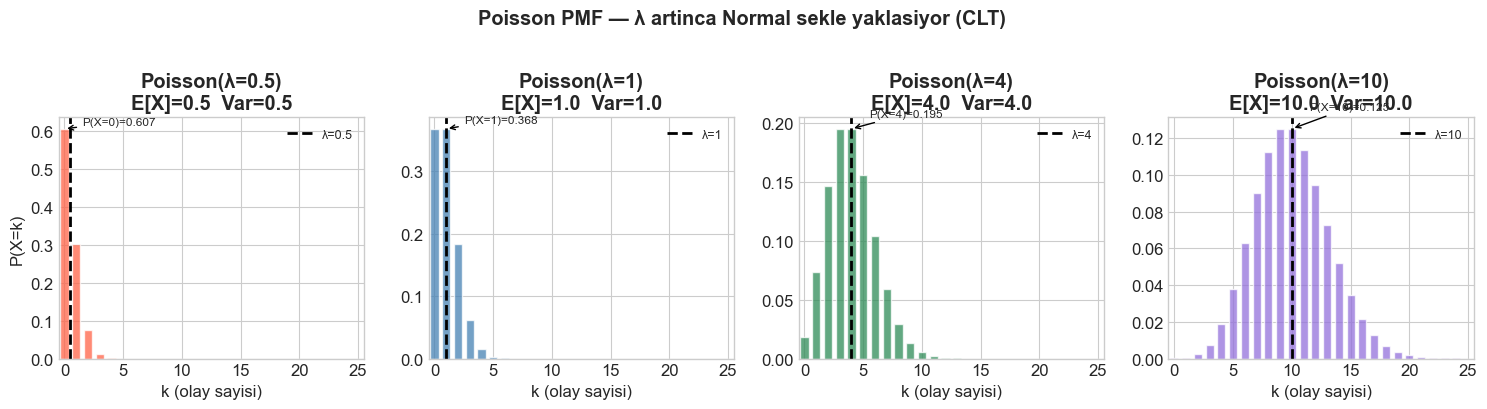

E[X] = Var(X) = lambda dogrulamasi:
  lambda= 0.5:  E[X]=0.5  Var(X)=0.5
  lambda= 1.0:  E[X]=1.0  Var(X)=1.0
  lambda= 4.0:  E[X]=4.0  Var(X)=4.0
  lambda=10.0:  E[X]=10.0  Var(X)=10.0


In [3]:
# Poisson PMF formulu kontrolu (manuel vs scipy)
import math
lam, k = 4, 2
pmf_manuel = (math.e**(-lam) * lam**k) / math.factorial(k)
pmf_scipy  = stats.poisson.pmf(k, mu=lam)
print(f'Manuel : e^(-4) * 4^2 / 2! = {pmf_manuel:.6f}')
print(f'SciPy  : stats.poisson.pmf({k}, mu={lam}) = {pmf_scipy:.6f}')
print()

# ─── PMF: farkli lambda degerleri ────────────────────────────────────────────
lambda_vals = [0.5, 1, 4, 10]
renkler     = ['tomato', 'steelblue', 'seagreen', 'mediumpurple']
k_max       = 25

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)

for ax, lam, renk in zip(axes, lambda_vals, renkler):
    dist   = stats.poisson(mu=lam)
    k_vals = np.arange(0, k_max + 1)
    pmf    = dist.pmf(k_vals)

    ax.bar(k_vals, pmf, color=renk, alpha=0.75, width=0.7, edgecolor='white')
    ax.axvline(lam, color='black', linestyle='--', linewidth=2,
               label=f'λ={lam}')

    # Vurgulanan k degerine etiket
    k_tepe = int(lam)     # tepe noktasi yaklasik floor(lambda)
    ax.annotate(f'P(X={k_tepe})={pmf[k_tepe]:.3f}',
                xy=(k_tepe, pmf[k_tepe]),
                xytext=(k_tepe + 1.5, pmf[k_tepe] + 0.01),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=8.5)

    ax.set_xlim(-0.5, k_max + 0.5)
    ax.set_xlabel('k (olay sayisi)')
    ax.set_ylabel('P(X=k)' if ax == axes[0] else '')
    ax.set_title(
        f'Poisson(λ={lam})\n'
        f'E[X]={dist.mean():.1f}  Var={dist.var():.1f}',
        fontweight='bold'
    )
    ax.legend(fontsize=9)

plt.suptitle('Poisson PMF — λ artinca Normal sekle yaklasiyor (CLT)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# E[X] = Var(X) = lambda dogrulamasi
print('E[X] = Var(X) = lambda dogrulamasi:')
for lam in lambda_vals:
    d = stats.poisson(lam)
    print(f'  lambda={lam:4.1f}:  E[X]={d.mean():.1f}  Var(X)={d.var():.1f}')


---
### 📉 Python 2 — Bike Sharing: CDF + Olasılık Soruları (`hour.csv`)

**Veri:** UCI Bike Sharing Dataset — `hour.csv`  
Her satır bir saatlik periyotu temsil ediyor; `cnt` o saatte kiralanan toplam bisiklet sayısı.  
Bu doğrudan bir **Poisson sayımıdır** — belirli bir sürede gerçekleşen olay sayısı.

**Ne yapıyoruz?**  
1. MLE ile $\hat{\lambda} = \bar{x}$ tahmin ediyoruz
2. Gözlemlenen dağılımı Poisson PMF ile karşılaştırıyoruz
3. CDF üzerinden olasılık soruları soruyoruz
4. Saat bazında (`hr`) ayrı lambda tahminleri çıkartıyoruz

**Anahtar kavramlar:**
- `bike['cnt'].mean()` → MLE tahmini $\hat{\lambda}$
- `Var(X) / E[X]` → **Dispersion indeksi**: 1'e yakınsa Poisson uygun, >1 ise overdispersed
- `.cdf(k)` → $P(X \leq k)$
- `1 - .cdf(k-1)` → $P(X \geq k)$

Yuklendi: 17379 satir, sutunlar: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
       dteday  hr  cnt
0  2011-01-01   0   16
1  2011-01-01   1   40
2  2011-01-01   2   32
3  2011-01-01   3   13
4  2011-01-01   4    1

Genel lambda_hat  = 189.46  (saatlik ort. kiralama)
Gozlemlenen Var   = 32899.57
Dispersion Var/E  = 173.65  (1.0 olmali; >1 ise overdispersion)


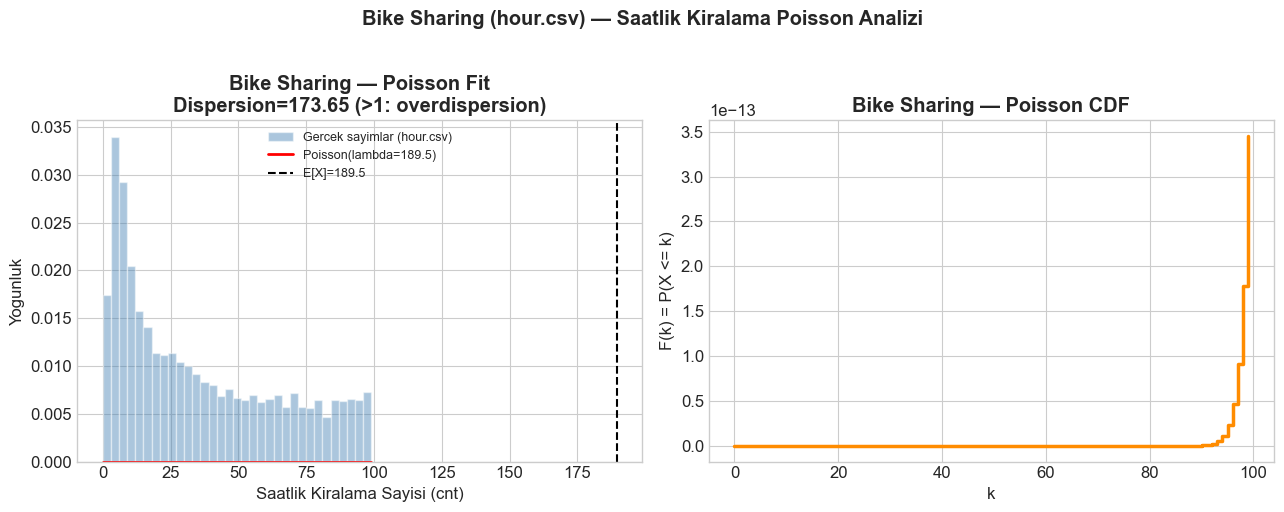


=== Poisson(lambda=189.5) Olaslik Sorulari ===
P(X <= 100)       = 0.0000
P(X >= 300)       = 0.0000
P(150<=X<=250)    = 0.9987
%90 yuzdelik      = 207 kiralama

=== Saat Bazli Lambda Tahminleri ===
 hr  lambda_hat      varyans  dispersion
  0   53.898072  1789.959251   33.210080
  1   33.375691  1124.846213   33.702560
  2   22.869930   706.424235   30.888780
  3   11.727403   175.276159   14.945863
  4    6.352941    17.171231    2.702879
  5   19.889819   174.260189    8.761276
  6   76.044138  3034.285342   39.901634
  7  212.064649 26063.498570  122.903552
  8  359.011004 55313.999879  154.073271
  9  219.309491  8780.337968   40.036288
 10  173.668501 10445.946431   60.148768
 11  208.143054 16255.111739   78.095865
 12  253.315934 21048.535537   83.092031
 13  253.661180 21935.878175   86.477080
 14  240.949246 21688.916376   90.014461
 15  251.233196 20918.571918   83.263566
 16  311.983562 22106.520991   70.857967
 17  461.452055 54129.098521  117.301674
 18  425.510989 50462

In [5]:
# hour.csv: UCI Bike Sharing saatlik kayitlar
# cnt = o saatte kiralanan bisiklet sayisi — doğal Poisson adayi
DATA_PATH = 'data'

bike = pd.read_csv(f'{DATA_PATH}/hour.csv')
print(f'Yuklendi: {len(bike)} satir, sutunlar: {list(bike.columns)}')
print(bike[['dteday','hr','cnt']].head())

# Lambda tahmini (MLE): lambda_hat = xbar = ortalama sayim
lam_hat = bike['cnt'].mean()
var_obs  = bike['cnt'].var(ddof=0) #ddof bize population variance verir, default ddof=1 sample variance verir

print(f'\nGenel lambda_hat  = {lam_hat:.2f}  (saatlik ort. kiralama)')
print(f'Gozlemlenen Var   = {var_obs:.2f}')
print(f'Dispersion Var/E  = {var_obs/lam_hat:.2f}  (1.0 olmali; >1 ise overdispersion)')

# ─── Poisson(lambda_hat) ile CDF ve olaslik sorulari ─────────────────────────
dist_genel = stats.poisson(mu=lam_hat)
k_max  = int(bike['cnt'].max()) + 5
k_vals = np.arange(0, min(k_max, 100))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# PMF: histogram (gercek) vs Poisson tahmini
ax1.hist(bike['cnt'], bins=range(0, min(k_max, 100), 3),
         density=True, color='steelblue', alpha=0.45,
         edgecolor='white', label='Gercek sayimlar (hour.csv)')
ax1.plot(k_vals, dist_genel.pmf(k_vals), 'r-', linewidth=2,
         label=f'Poisson(lambda={lam_hat:.1f})')
ax1.axvline(lam_hat, color='black', linestyle='--', linewidth=1.5,
            label=f'E[X]={lam_hat:.1f}')
ax1.set_xlabel('Saatlik Kiralama Sayisi (cnt)')
ax1.set_ylabel('Yogunluk')
ax1.set_title(
    f'Bike Sharing — Poisson Fit\n'
    f'Dispersion={var_obs/lam_hat:.2f} (>1: overdispersion)',
    fontweight='bold'
)
ax1.legend(fontsize=9)

# CDF — olaslik okuma
cdf_vals = dist_genel.cdf(k_vals)
ax2.step(k_vals, cdf_vals, where='post', color='darkorange', linewidth=2.5)
for k_q, renk in [(100,'red'), (int(lam_hat),'green'), (300,'purple')]:
    if k_q <= k_vals[-1]:
        cdf_q = dist_genel.cdf(k_q)
        ax2.scatter([k_q], [cdf_q], color=renk, s=80, zorder=5)
        ax2.plot([k_q, k_q], [0, cdf_q], color=renk, linestyle=':', alpha=0.7)
        ax2.text(k_q + 1, cdf_q - 0.08, f'F({k_q})={cdf_q:.3f}',
                 color=renk, fontsize=9)
ax2.set_xlabel('k')
ax2.set_ylabel('F(k) = P(X <= k)')
ax2.set_title('Bike Sharing — Poisson CDF', fontweight='bold')

plt.suptitle('Bike Sharing (hour.csv) — Saatlik Kiralama Poisson Analizi',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Olaslik sorulari (genel lambda ile) ──────────────────────────────────────
print(f'\n=== Poisson(lambda={lam_hat:.1f}) Olaslik Sorulari ===')
print(f'P(X <= 100)       = {dist_genel.cdf(100):.4f}')
print(f'P(X >= 300)       = {1-dist_genel.cdf(299):.4f}')
print(f'P(150<=X<=250)    = {dist_genel.cdf(250)-dist_genel.cdf(149):.4f}')
print(f'%90 yuzdelik      = {int(dist_genel.ppf(0.90))} kiralama')

# ─── Saat bazli lambda (alt grup analizi) ─────────────────────────────────────
saat_ozet = bike.groupby('hr')['cnt'].agg(
    lambda_hat='mean', varyans='var', n='count'
).reset_index()
saat_ozet['dispersion'] = saat_ozet['varyans'] / saat_ozet['lambda_hat']

print(f'\n=== Saat Bazli Lambda Tahminleri ===')
print(saat_ozet[['hr','lambda_hat','varyans','dispersion']].to_string(index=False))


---
### 📋 Python 2 — Sonuç ve Yorumlama

## Ne bulduk?

| Metrik | Değer | Beklenen (Poisson) |
|---|---:|---:|
| $\hat{\lambda}$ (genel) | **189.5 kiralama/saat** | — |
| Gözlemlenen Varyans | **32,899** | $\approx 189.5$ |
| **Dispersion (Var/E[X])** | **173.65** | **1.0** |

---

## ❗ Neden Poisson Fit Başarısız?

### Overdispersion

Varyans, Poisson dağılımının beklediğinden yaklaşık **173 kat daha büyük**.

Bu durum, verinin Poisson varsayımlarından en az birini ihlal ettiğini gösterir.

### Asıl neden — Homojenlik ihlali

Poisson dağılımı, olayların zaman boyunca **aynı yoğunlukta** gerçekleştiğini varsayar.

Ancak bisiklet kiralamalarında $\lambda$;

- saate,
- güne,
- mevsime,
- hava durumuna

göre ciddi biçimde değişmektedir.

Örneğin:

```text
Saat 04 (gece)      → λ ≈   6 kiralama
Saat 17 (rush hour) → λ ≈ 461 kiralama
```

Tüm gözlemleri tek bir

$$
\lambda = 189.5
$$

ile modellemek, gece saatleri ile mesai çıkışını aynı dağılım altında değerlendirmek anlamına gelir.

Bu nedenle oluşan dağılım tek bir Poisson değil,

> **Farklı λ değerlerine sahip Poisson dağılımlarının karışımı (Mixture of Poissons)**

şeklindedir.

---

## Sol Grafik — Histogram vs. Poisson Fit

- **Mavi histogram:** Gerçek veri dağılımını gösterir.
  - 0–100+ arasında sağa çarpık yapı
  - Gece ve gündüzü temsil eden iki farklı yoğunluk görülmektedir.

- **Kırmızı eğri:** Poisson(189.5) modeli.

Poisson(189.5) dağılımı olasılık kütlesinin neredeyse tamamını **160–220** aralığında topladığı için,

$$
P(X<100)\approx0
$$

olmaktadır.

Bu nedenle kırmızı eğri grafik üzerinde neredeyse görünmez.

### Sonuç

Gerçek histogram ile teorik Poisson eğrisi tamamen farklı bölgelerde yer almaktadır.

**Poisson modeli veriyi açıklayamamaktadır.**

---

## Sağ Grafik — CDF Yorumu

CDF grafiğinde y ekseninin

```text
1e−13
```

ölçeğinde görünmesi ilk bakışta garip görünse de bunun nedeni modelin başarısız olmasıdır.

Poisson(189.5) modeline göre

$$
P(X\le100)\approx0
$$

olduğu için CDF neredeyse sıfır seviyesinde kalmaktadır.

Oysa gerçek verinin önemli bir kısmı **0–100 kiralama** aralığında bulunmaktadır.

Bu grafik, model ile gerçek veri arasındaki uyumsuzluğu açık biçimde göstermektedir.

---

## Saat Bazlı Dispersion Analizi

Her saat kendi içinde ayrı incelendiğinde bile dispersion değeri yüksek kalmaktadır.

| Saat | $\hat{\lambda}$ | Dispersion | Yorum |
|---|---:|---:|---|
| 04 (gece) | 6.4 | **2.7** | En iyi sonuç; yine de >1 |
| 08 (sabah yoğunluğu) | 359 | **154** | Çok yüksek overdispersion |
| 17 (akşam yoğunluğu) | 461 | **117** | Çok yüksek overdispersion |

Saat bazında analiz yapmak varyansı azaltmaktadır; ancak

- mevsim,
- hava durumu,
- tatil / iş günü,
- kullanıcı davranışı

gibi ek değişkenler hâlâ önemli varyans kaynaklarıdır.

---

## ✅ Daha Doğru Yaklaşım

Poisson dağılımını doğrudan tüm veri üzerine uygulamak yerine aşağıdaki yöntemler tercih edilmelidir.

1. **Homojen alt gruplar oluştur**

   Örneğin:

   ```text
   hr = 17
   workingday = 1
   weathersit = 1
   ```

   gibi benzer koşullardaki gözlemleri birlikte analiz etmek.

2. **Negatif Binom Dağılımı**

   Overdispersion'ı modelleyen ek parametre içerdiği için Poisson'a göre daha uygundur.

3. **Poisson Regresyonu (GLM)**

   $\lambda$ değerini;

   - saat,
   - mevsim,
   - hava durumu,
   - tatil bilgisi

   gibi açıklayıcı değişkenlere bağlayarak her gözlem için farklı bir beklenen değer tahmin edilir.

---

## 📌 Çıkarım

> Gerçek verilere Poisson dağılımı uygulamadan önce mutlaka

$$
\frac{\operatorname{Var}(X)}{E[X]}
$$

oranı hesaplanmalıdır.

- **≈ 1** → Poisson modeli uygundur.
- **≫ 1** → Veri overdispersion içerir ve daha gelişmiş modeller (Negatif Binom, GLM vb.) tercih edilmelidir.

---
### 🔬 Python 3 — Poisson Limit Teoremi: Binomial ile Karşılaştırma

**Ne yapıyoruz?**  
$\lambda = np$ sabit tutarak $n$ artırıp Binomial'ın Poisson'a yaklaştığını görüyoruz.

**Mantık:**
- $n$ büyüdükçe, $p = \lambda/n$ küçülür
- Binomial PMF → Poisson PMF'e yaklaşır
- Farkın nasıl azaldığı: maksimum mutlak sapma ile ölçülüyor

Bu grafik, **neden Binomial yerine Poisson kullandığımızı** görsel olarak açıklar.

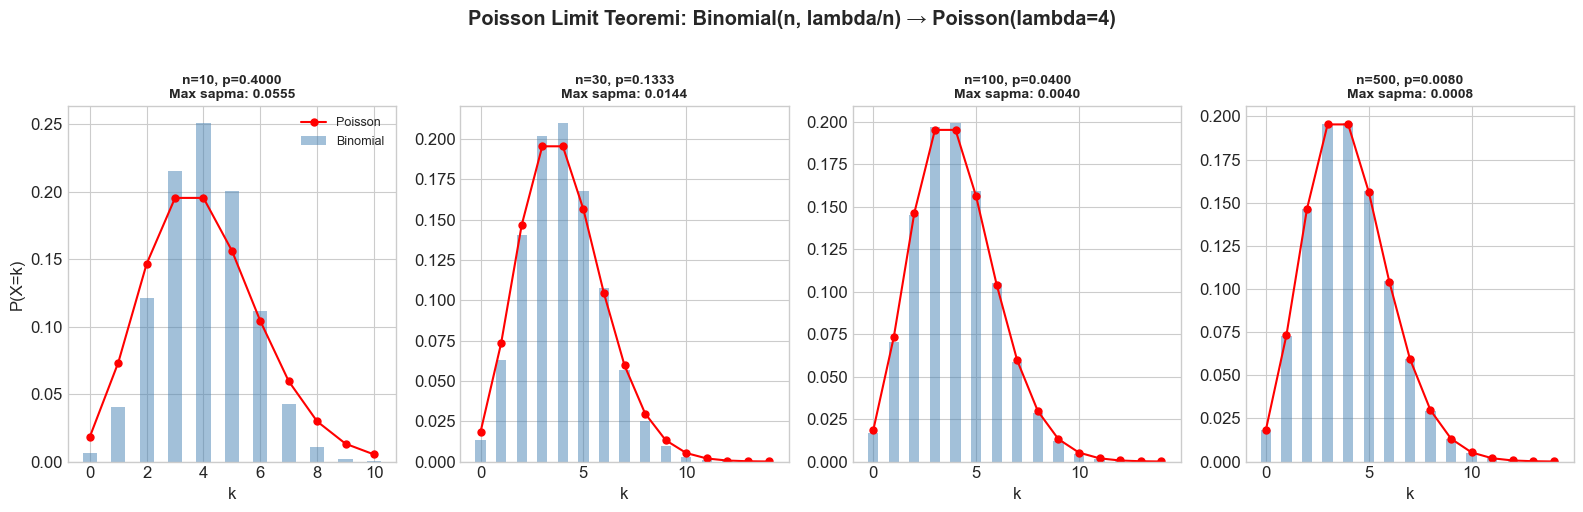

     n          p    Max Sapma
     5    0.80000     0.214233
    10    0.40000     0.055456
    30    0.13333     0.014401
   100    0.04000     0.004022
   500    0.00800     0.000786
  1000    0.00400     0.000392


In [6]:
lam_sabit = 4    # lambda = np = sabit
n_vals    = [10, 30, 100, 500]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
poisson_ref = stats.poisson(mu=lam_sabit)

for ax, n in zip(axes, n_vals):
    p = lam_sabit / n          # p = lambda/n → n buyudukce p kuculuyor
    binom_dist = stats.binom(n=n, p=p)

    k_max = min(n, int(lam_sabit + 5 * np.sqrt(lam_sabit)))
    k_vals = np.arange(0, k_max + 1)

    pmf_binom   = binom_dist.pmf(k_vals)
    pmf_poisson = poisson_ref.pmf(k_vals)
    max_sapma   = np.max(np.abs(pmf_binom - pmf_poisson))

    # Binomial cubuk
    ax.bar(k_vals, pmf_binom, width=0.5, color='steelblue', alpha=0.5,
           label='Binomial')
    # Poisson cizgi
    ax.plot(k_vals, pmf_poisson, 'ro-', markersize=5, linewidth=1.5,
            label='Poisson')

    ax.set_title(
        f'n={n}, p={p:.4f}\n'
        f'Max sapma: {max_sapma:.4f}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('k')
    ax.set_ylabel('P(X=k)' if n == n_vals[0] else '')
    if n == n_vals[0]:
        ax.legend(fontsize=9)

plt.suptitle(
    f'Poisson Limit Teoremi: Binomial(n, lambda/n) → Poisson(lambda={lam_sabit})',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Maksimum sapma tablosu
print(f'{"n":>6} {"p":>10} {"Max Sapma":>12}')
for n in [5, 10, 30, 100, 500, 1000]:
    p   = lam_sabit / n
    k_r = np.arange(0, 25)
    sap = np.max(np.abs(stats.binom.pmf(k_r, n, p) - poisson_ref.pmf(k_r)))
    print(f'{n:>6} {p:>10.5f} {sap:>12.6f}')


---
### ⏱️ Python 4 — Poisson Süreci: Gelişler Arası Süre (Üstel Dağılım)

**Ne yapıyoruz?**  
Poisson sürecini simüle ediyoruz: olaylar arasındaki bekleme süresi **Üstel dağılım** izler.

**Mantık:**
- Olaylar arası süre $T \sim \text{Exp}(\lambda)$ → ortalama bekleme $1/\lambda$
- `stats.expon(scale=1/lam).rvs(n)` → $n$ bekleme süresi simüle et
- `np.cumsum(bekleme_sureleri)` → her olayın gerçekleştiği zaman
- Birim aralıklara bölünce Poisson sayımları elde ediliyor

Bu bağlantı çok önemli: **Sürekli ↔ Kesikli** köprüsü.  
Üstel dağılımı ilerideki notebook'ta ayrıntılı göreceğiz.

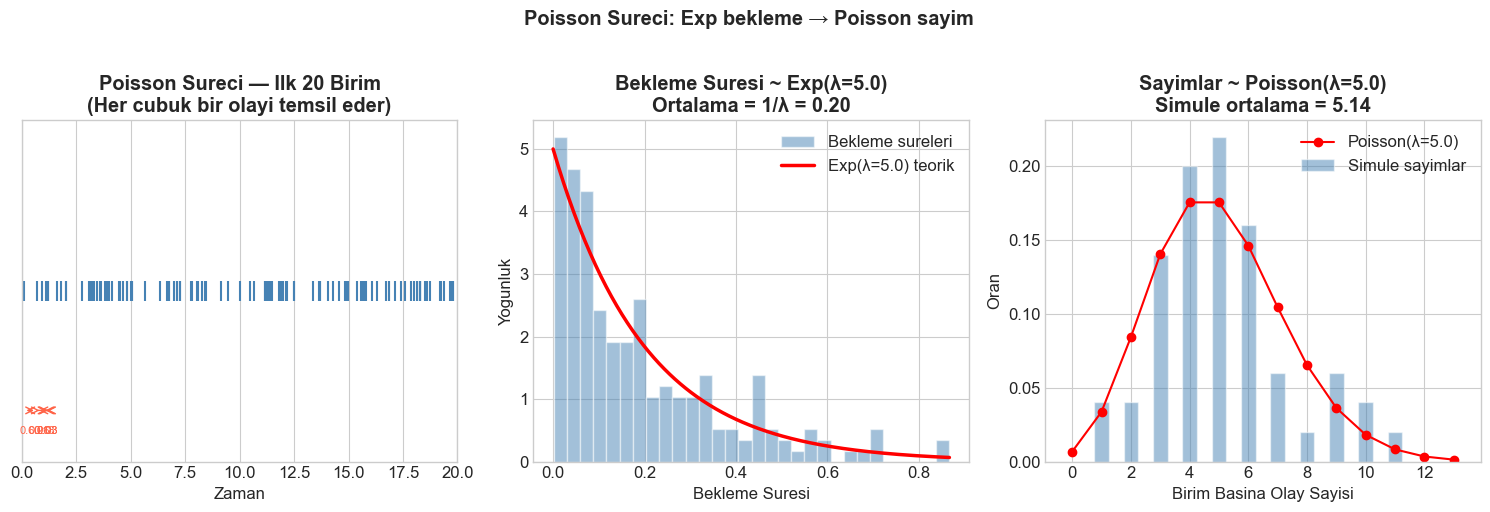

Toplam simule olay sayisi : 257
Birim basina ortalama     : 5.1400  (lambda=5.0 olmali)
Birim basina varyans      : 5.0004  (Var=lambda=5.0 olmali)
Oran (mean/var)           : 1.0279  (1.0 olmali - Poisson)


In [10]:
rng      = np.random.default_rng(42)
lam      = 5.0        # saatte 5 olay
T_sim    = 50.0       # 50 birimlik simülasyon penceresi

# Olaylar arasi bekleme sureleri ~ Exp(lambda)
# scale = 1/lambda (scipy'da Üstel için)
bekleme  = stats.expon(scale=1/lam).rvs(size=1000, random_state=42)
zamanlar = np.cumsum(bekleme)       # olaylarin gerceklestigi zamanlar
zamanlar = zamanlar[zamanlar < T_sim]  # T_sim icerisindeki olaylar

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─── Sol: Olay zaman cizgisi ─────────────────────────────────────────────────
ax = axes[0]
ax.scatter(zamanlar, np.ones_like(zamanlar), marker='|', s=200,
           color='steelblue', linewidth=1.5)
ax.set_xlim(0, 20)    # ilk 20 birimi goster
ax.set_ylim(0.5, 1.5)
ax.set_yticks([])
ax.set_xlabel('Zaman')
ax.set_title('Poisson Sureci — Ilk 20 Birim\n(Her cubuk bir olayi temsil eder)', fontweight='bold')

# Bekleme surelerini goster
for i in range(min(5, len(zamanlar)-1)):
    ax.annotate('', xy=(zamanlar[i+1], 0.65), xytext=(zamanlar[i], 0.65),
                arrowprops=dict(arrowstyle='<->', color='tomato'))
    mid = (zamanlar[i] + zamanlar[i+1]) / 2
    ax.text(mid, 0.58, f'{zamanlar[i+1]-zamanlar[i]:.2f}', ha='center',
            fontsize=8, color='tomato')

# ─── Orta: Bekleme suresi histogrami (Ustel dagilim fit) ─────────────────────
ax = axes[1]
ax.hist(bekleme[:200], bins=30, density=True, color='steelblue', alpha=0.5,
        edgecolor='white', label='Bekleme sureleri')

x_exp = np.linspace(0, bekleme[:200].max(), 300)
ax.plot(x_exp, stats.expon(scale=1/lam).pdf(x_exp),
        'r-', linewidth=2.5, label=f'Exp(λ={lam}) teorik')

ax.set_xlabel('Bekleme Suresi')
ax.set_ylabel('Yogunluk')
ax.set_title(f'Bekleme Suresi ~ Exp(λ={lam})\nOrtalama = 1/λ = {1/lam:.2f}', fontweight='bold')
ax.legend()

# ─── Sag: Birim basi sayim histogrami (Poisson fit) ──────────────────────────
ax = axes[2]
# Birim araliklar: [0,1), [1,2), ...
araliklar = np.floor(zamanlar).astype(int)
sayimlar  = np.bincount(araliklar, minlength=int(T_sim))
sayimlar  = sayimlar[:int(T_sim)]

k_max = sayimlar.max() + 2
k_vals = np.arange(0, k_max + 1)
frekans = np.bincount(sayimlar, minlength=k_max+1) / len(sayimlar)

ax.bar(k_vals, frekans, color='steelblue', alpha=0.5, width=0.5,
       edgecolor='white', label='Simule sayimlar')
ax.plot(k_vals, stats.poisson.pmf(k_vals, mu=lam),
        'ro-', markersize=6, linewidth=1.5, label=f'Poisson(λ={lam})')

ax.set_xlabel('Birim Basina Olay Sayisi')
ax.set_ylabel('Oran')
ax.set_title(f'Sayimlar ~ Poisson(λ={lam})\nSimule ortalama = {sayimlar.mean():.2f}', fontweight='bold')
ax.legend()

plt.suptitle('Poisson Sureci: Exp bekleme → Poisson sayim', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Toplam simule olay sayisi : {len(zamanlar)}')
print(f'Birim basina ortalama     : {sayimlar.mean():.4f}  (lambda={lam} olmali)')
print(f'Birim basina varyans      : {sayimlar.var():.4f}  (Var=lambda={lam} olmali)')
print(f'Oran (mean/var)           : {sayimlar.mean()/sayimlar.var():.4f}  (1.0 olmali - Poisson)')


---
### 🗽 Python 5 — NYC 311 Service Requests: Saatlik Şikayet Sayısı

**Veri:** NYC 311 Service Requests — `311_Service_Requests_from_2010_to_Present.csv`  
Her satır bir şikayet kaydı; `Created Date` alanından saatlik pencere bazında sayım yapıyoruz.  
**"Saatte kaç şikayet gelir?"** → Poisson modeli için klasik bir kullanım senaryosu.

**Ne yapıyoruz?**
1. 53 sütunlu büyük dosyadan sadece 4 sütun yüklüyoruz (bellek tasarrufu)
2. `Created Date` → `dt.floor('h')` ile saatlik pencereye yuvarlıyoruz
3. Her penceredeki satır sayısını sayıyoruz → Poisson sayımı
4. Genel fit + saat deseni + şikayet türü bazında overdispersion analizi yapıyoruz

**Anahtar kavramlar:**
- `usecols=[...]` → büyük CSV'den sadece gerekli sütunları yükle
- `dt.floor('h')` → Python'da `DATE_TRUNC('hour', ...)` karşılığı
- `groupby('saat_penceresi').size()` → her saatte kaç olay? → Poisson sayımı
- Şikayet türü bazında analiz: Poisson varsayımı her türde eşit geçerli mi?

> **Beklenen bulgu:** Genel fit overdispersed görünür (Var/E >> 1)  
> çünkü şikayet yoğunluğu saat ve güne göre değişiyor (homojenlik ihlali).  
> Belirli bir şikayet türünü sabit bir saatte incelediğinde fit iyileşir.

/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_93044/2226358756.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nyc = pd.read_csv(


Yuklendi: 364,558 satir
Unique Key                 int64
Created Date      datetime64[ns]
Complaint Type            object
Borough                   object
dtype: object
   Unique Key        Created Date           Complaint Type    Borough
0    32310363 2015-12-31 23:59:45  Noise - Street/Sidewalk  MANHATTAN
1    32309934 2015-12-31 23:59:44         Blocked Driveway     QUEENS
2    32309159 2015-12-31 23:59:29         Blocked Driveway      BRONX

Toplam saat penceresi: 8,758
lambda_hat (MLE)     : 41.63  sikayet/saat
Gozlemlenen Var      : 526.97
Dispersion Var/E     : 12.66


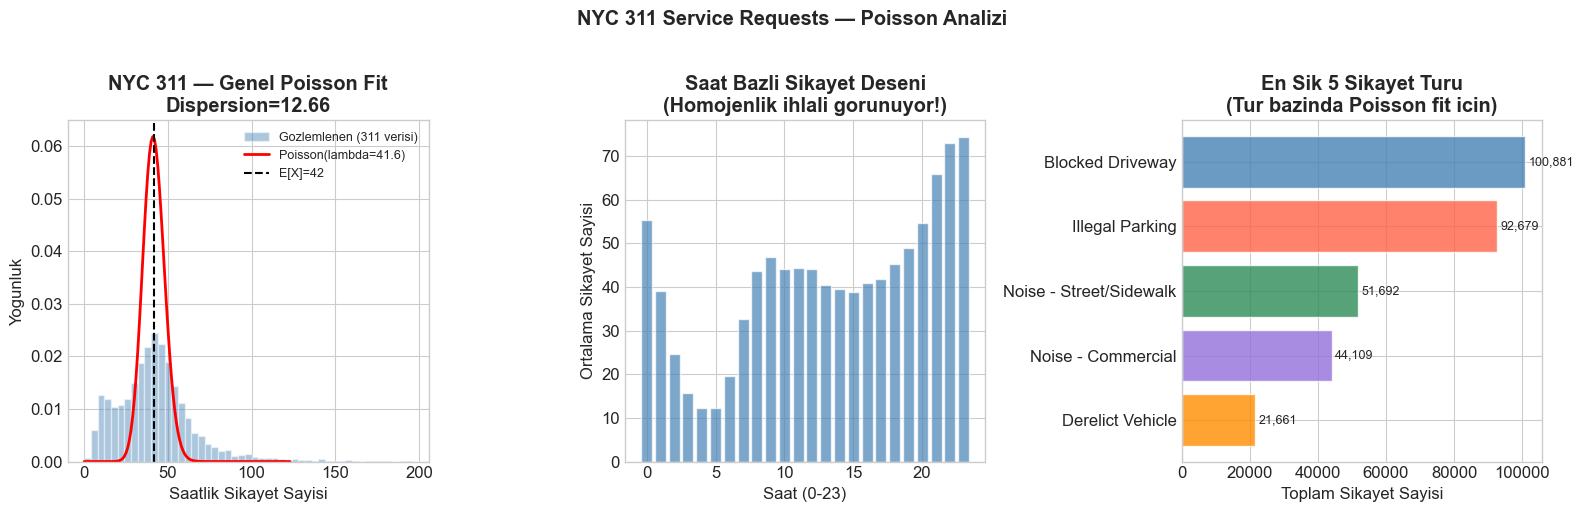


=== Sikayet Turu Bazinda Poisson Fit Kalitesi ===
         Complaint Type  lambda_hat    varyans  dispersion
       Blocked Driveway   11.622235  36.469214    3.137883
        Illegal Parking   10.776628  38.192569    3.544019
Noise - Street/Sidewalk    7.321813 107.349602   14.661615
     Noise - Commercial    6.111819  62.398110   10.209417
       Derelict Vehicle    3.529575   6.081304    1.722957
        Noise - Vehicle    2.942375   7.344155    2.495995
  Posting Advertisement    2.332192   2.985489    1.280122
           Animal Abuse    2.015488   1.591460    0.789615
           Noise - Park    1.957599   2.755589    1.407637
                Vending    1.715923   1.305017    0.760533

Dispersion ~ 1.0 olan turler Poisson modeline daha uygun.


In [11]:
# 311_Service_Requests_from_2010_to_Present.csv
# Created Date → saatlik sikayet sayisi = Poisson sayimi
DATA_PATH = 'data'

# Buyuk dosya — sadece ihtiyac duyulan sutunlari yukle
nyc = pd.read_csv(
    f'{DATA_PATH}/311_Service_Requests_from_2010_to_Present.csv',
    usecols=['Unique Key', 'Created Date', 'Complaint Type', 'Borough'],
    parse_dates=['Created Date']
)
print(f'Yuklendi: {len(nyc):,} satir')
print(nyc.dtypes)
print(nyc.head(3))

# ─── Saatlik sikayet sayisini hesapla ─────────────────────────────────────────
# Her satir bir sikayet = bir Poisson olayi
# DATE_TRUNC('hour') karsiligi: dt.floor('h')
nyc['saat_penceresi'] = nyc['Created Date'].dt.floor('h')
saatlik_sayim = (
    nyc.groupby('saat_penceresi')
       .size()
       .reset_index(name='sikayet_sayisi')
)

lam_nyc = saatlik_sayim['sikayet_sayisi'].mean()
var_nyc  = saatlik_sayim['sikayet_sayisi'].var(ddof=0)

print(f'\nToplam saat penceresi: {len(saatlik_sayim):,}')
print(f'lambda_hat (MLE)     : {lam_nyc:.2f}  sikayet/saat')
print(f'Gozlemlenen Var      : {var_nyc:.2f}')
print(f'Dispersion Var/E     : {var_nyc/lam_nyc:.2f}')

# ─── Grafik: histogram vs Poisson vs saat deseni ─────────────────────────────
dist_nyc = stats.poisson(mu=lam_nyc)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sol: genel histogram vs Poisson fit
ax = axes[0]
k_plot = np.arange(0, int(saatlik_sayim['sikayet_sayisi'].quantile(0.99)) + 1)
ax.hist(
    saatlik_sayim['sikayet_sayisi'],
    bins=range(0, int(saatlik_sayim['sikayet_sayisi'].max()) + 2, max(1, int(lam_nyc)//10)),
    density=True, color='steelblue', alpha=0.45,
    edgecolor='white', label='Gozlemlenen (311 verisi)'
)
ax.plot(k_plot, dist_nyc.pmf(k_plot), 'r-', linewidth=2,
        label=f'Poisson(lambda={lam_nyc:.1f})')
ax.axvline(lam_nyc, color='black', linestyle='--', linewidth=1.5,
           label=f'E[X]={lam_nyc:.0f}')
ax.set_xlabel('Saatlik Sikayet Sayisi')
ax.set_ylabel('Yogunluk')
ax.set_title(
    f'NYC 311 — Genel Poisson Fit\nDispersion={var_nyc/lam_nyc:.2f}',
    fontweight='bold'
)
ax.legend(fontsize=9)

# Orta: saat deseni (gunde ortalama sikayet)
ax = axes[1]
nyc['saat'] = nyc['Created Date'].dt.hour
saat_ort = nyc.groupby('saat').size() / nyc['Created Date'].dt.date.nunique()
ax.bar(saat_ort.index, saat_ort.values, color='steelblue', alpha=0.7,
       edgecolor='white')
ax.set_xlabel('Saat (0-23)')
ax.set_ylabel('Ortalama Sikayet Sayisi')
ax.set_title(
    'Saat Bazli Sikayet Deseni\n(Homojenlik ihlali gorunuyor!)',
    fontweight='bold'
)

# Sag: En sik sikayet turleri (ilk 5)
ax = axes[2]
top5 = nyc['Complaint Type'].value_counts().head(5)
colors = ['steelblue','tomato','seagreen','mediumpurple','darkorange']
bars = ax.barh(top5.index[::-1], top5.values[::-1],
               color=colors[::-1], alpha=0.8, edgecolor='white')
for bar, val in zip(bars, top5.values[::-1]):
    ax.text(bar.get_width() + top5.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Toplam Sikayet Sayisi')
ax.set_title('En Sik 5 Sikayet Turu\n(Tur bazinda Poisson fit icin)', fontweight='bold')

plt.suptitle('NYC 311 Service Requests — Poisson Analizi', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ─── Tur bazinda overdispersion ───────────────────────────────────────────────
print('\n=== Sikayet Turu Bazinda Poisson Fit Kalitesi ===')
tur_saatlik = (
    nyc.groupby(['saat_penceresi', 'Complaint Type'])
       .size()
       .reset_index(name='sayim')
)
tur_ozet = (
    tur_saatlik.groupby('Complaint Type')['sayim']
               .agg(lambda_hat='mean', varyans='var')
               .reset_index()
)
tur_ozet['dispersion'] = tur_ozet['varyans'] / tur_ozet['lambda_hat']
tur_ozet = tur_ozet[tur_ozet['lambda_hat'] >= 1.0].sort_values('lambda_hat', ascending=False)
print(tur_ozet.head(10).to_string(index=False))
print('\nDispersion ~ 1.0 olan turler Poisson modeline daha uygun.')


---
# 📊 R Uygulaması

R'da Poisson için 4 hazır fonksiyon (Binomial ile aynı mantık):

| Fonksiyon | Ne yapar? | Python karşılığı |
|---|---|---|
| `dpois(k, lambda)` | $P(X=k)$ — PMF | `stats.poisson.pmf(k, mu=lam)` |
| `ppois(q, lambda)` | $P(X \leq q)$ — CDF | `stats.poisson.cdf(q, mu=lam)` |
| `qpois(p, lambda)` | Quantile | `stats.poisson.ppf(p, mu=lam)` |
| `rpois(n, lambda)` | Rastgele örnekleme | `stats.poisson.rvs(mu=lam, size=n)` |

In [12]:
%load_ext rpy2.ipython


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🎲 R 1 — Poisson PMF, CDF ve Olasılık Soruları

**Yeni R kavramı:** `which.max()`  
Bir vektörde maksimum değerin **indeksini** (konumunu) döndürür.  
PMF'in tepe noktasını (en yüksek olasılıklı $k$ değerini) bulmak için kullanıyoruz.

```r
which.max(pmf_vals)   # → tepe noktasinin indeksi
# eşdeğer Python: np.argmax(pmf)
```


=== Cagri Merkezi: Poisson(lambda=12) ===
P(X <= 8)       = 0.155 
P(X >= 15)      = 0.228 
P(8 <= X <= 16) = 0.8092 
P(X = 12)       = 0.1144 
%95 yuzdelik    = 18 


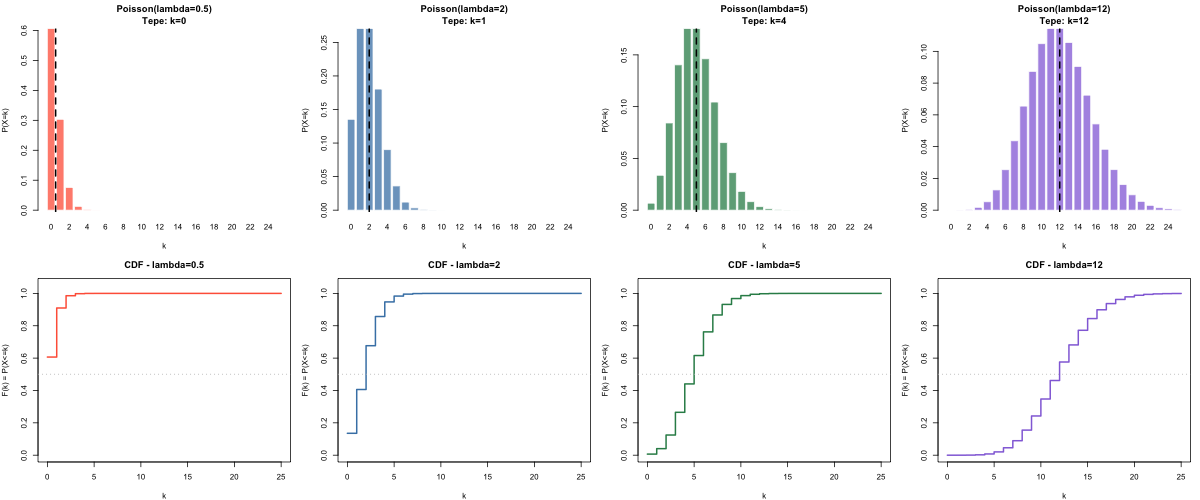

In [15]:
%%R -w 1200 -h 500
lambda_vals <- c(0.5, 2, 5, 12)
renkler     <- c('tomato', 'steelblue', 'seagreen', 'mediumpurple')

par(mfrow = c(2, 4), mar = c(4, 4, 3, 1))

# ─── Ust sira: PMF ────────────────────────────────────────────────────────────
for (i in seq_along(lambda_vals)) {
  lam    <- lambda_vals[i]
  k_seq  <- 0:25
  pmf_v  <- dpois(k_seq, lambda = lam)   # PMF: dpois(k, lambda)

  # Tepe noktasi: which.max → Python'daki np.argmax()
  k_tepe <- k_seq[which.max(pmf_v)]

  barplot(
    pmf_v,
    names.arg = k_seq,
    col       = adjustcolor(renkler[i], alpha.f = 0.75),
    border    = 'white',
    main      = paste0('Poisson(lambda=', lam, ')\nTepe: k=', k_tepe),
    xlab      = 'k',
    ylab      = 'P(X=k)'
  )
  # Beklenti isaretcisi (lambda degerinde)
  # Barplot'ta x koordinati 1.2*k + 0.7 yaklasimi
  abline(v = (lam) * 1.2 + 0.7, col = 'black', lty = 2, lwd = 2)
}

# ─── Alt sira: CDF ───────────────────────────────────────────────────────────
for (i in seq_along(lambda_vals)) {
  lam   <- lambda_vals[i]
  k_seq <- 0:25
  # ppois: kumulatif CDF (Python'daki dist.cdf() ile ayni)
  cdf_v <- ppois(k_seq, lambda = lam)

  plot(
    k_seq, cdf_v,
    type = 's',           # step/merdiven
    col  = renkler[i],
    lwd  = 2,
    ylim = c(0, 1.05),
    main = paste0('CDF - lambda=', lam),
    xlab = 'k',
    ylab = 'F(k) = P(X<=k)'
  )
  abline(h = 0.5, col = 'gray', lty = 3)
}

par(mfrow = c(1, 1))

# ─── Olaslik sorulari (cagri merkezi: lambda=12) ─────────────────────────────
lam <- 12
cat('\n=== Cagri Merkezi: Poisson(lambda=12) ===\n')
cat('P(X <= 8)       =', round(ppois(8,  lam), 4), '\n')
cat('P(X >= 15)      =', round(1 - ppois(14, lam), 4), '\n')
cat('P(8 <= X <= 16) =', round(ppois(16, lam) - ppois(7, lam), 4), '\n')
cat('P(X = 12)       =', round(dpois(12, lam), 4), '\n')
cat('%95 yuzdelik    =', qpois(0.95, lam), '\n')


---
### 🔬 R 2 — Poisson Simülasyonu + Binomial Karşılaştırma

**Yeni R kavramı:** `replicate(n, expr)`  
Bir ifadeyi $n$ kez çalıştırır ve sonuçları toplar.  
Python'daki `[expr for _ in range(n)]` veya `np.array([...])` gibi.

```r
replicate(1000, rpois(1, lambda=5))
# eşdeğer Python: stats.poisson.rvs(mu=5, size=1000)
```


=== Simulasyon Ozeti ===
Gercek lambda      : 5 
Simulasyon ort.    : 5.0356 
Simulasyon varyans : 5.0669 
Oran Var/E         : 1.0062 (1.0 olmali)


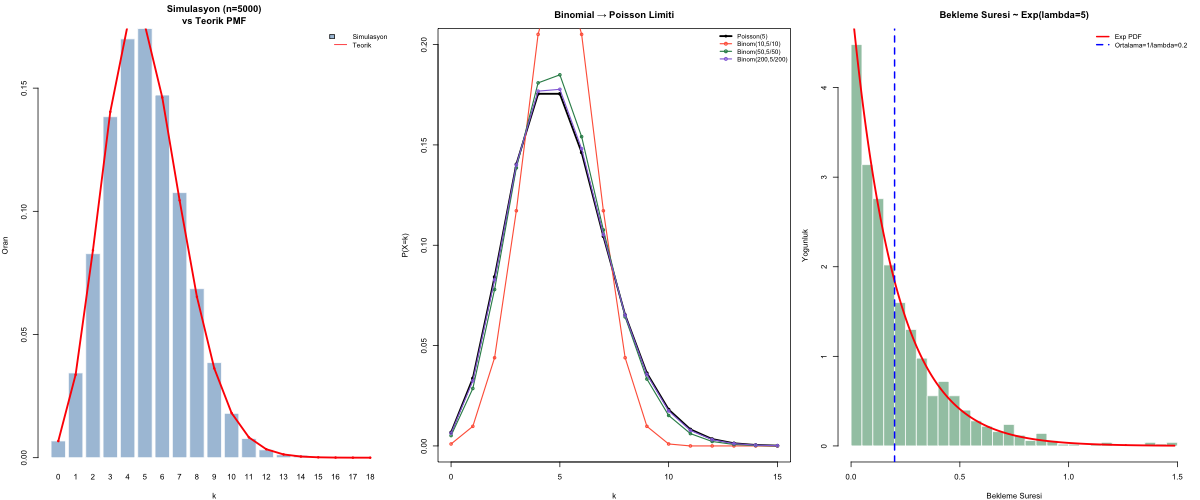

In [16]:
%%R -w 1200 -h 500
set.seed(42)

lam   <- 5.0
n_sim <- 5000

# rpois: Poisson rastgele ornekleme (Python stats.poisson.rvs ile ayni)
simulasyon <- rpois(n_sim, lambda = lam)

par(mfrow = c(1, 3), mar = c(4, 4, 3, 1))

# ─── Sol: Simulasyon histogrami vs teorik PMF ─────────────────────────────────
k_max <- 18
k_seq <- 0:k_max

# table(): frekans tablosu (Python value_counts() gibi)
frekans <- table(factor(simulasyon, levels = k_seq))
oran    <- as.numeric(frekans) / n_sim

barplot(oran,
        names.arg = k_seq,
        col       = adjustcolor('steelblue', 0.5),
        border    = 'white',
        main      = paste0('Simulasyon (n=', n_sim, ')\nvs Teorik PMF'),
        xlab      = 'k',
        ylab      = 'Oran')

# Teorik PMF uzerine ciz
teorik <- dpois(k_seq, lambda = lam)
# barplot x koordinatlari: 1.2*(0:k_max) + 0.7
lines(1.2 * k_seq + 0.7, teorik, col = 'red', lwd = 2.5, type = 'o', pch = 16, cex = 0.7)

legend('topright', legend = c('Simulasyon', 'Teorik'),
       fill = c(adjustcolor('steelblue',0.5), NA),
       col  = c(NA, 'red'), lty = c(NA,1), border=c('black',NA),
       bty='n', cex=0.85)

# ─── Orta: Binom vs Poisson limiti ────────────────────────────────────────────
n_list <- c(10, 50, 200)
renkler_b <- c('tomato', 'seagreen', 'mediumpurple')
k_show <- 0:15

plot(k_show, dpois(k_show, lam), type='o', pch=16, col='black', lwd=2.5,
     ylim=c(0, 0.20), main='Binomial → Poisson Limiti',
     xlab='k', ylab='P(X=k)')

for (j in seq_along(n_list)) {
  n_j <- n_list[j]
  p_j <- lam / n_j
  lines(k_show, dbinom(k_show, n_j, p_j),
        type='o', pch=1, col=renkler_b[j], lwd=1.5, cex=0.7)
}

legend('topright',
       legend = c('Poisson(5)', paste0('Binom(', n_list, ',5/', n_list, ')')),
       col    = c('black', renkler_b),
       lwd    = c(2.5, rep(1.5,3)), pch=c(16,rep(1,3)),
       bty='n', cex=0.8)

# ─── Sag: Bekleme suresi (Ustel dagilim) ─────────────────────────────────────
# rexp: Ustel rastgele sayi (Python stats.expon.rvs ile ayni)
# scale = 1/lambda
bekleme_r <- rexp(1000, rate = lam)    # rate = lambda (scipy'da scale=1/lam)

hist(bekleme_r, breaks=30, freq=FALSE,
     col=adjustcolor('seagreen', 0.5), border='white',
     main=paste0('Bekleme Suresi ~ Exp(lambda=', lam, ')'),
     xlab='Bekleme Suresi', ylab='Yogunluk')

x_e <- seq(0, max(bekleme_r), length.out=300)
lines(x_e, dexp(x_e, rate=lam), col='red', lwd=2.5)
abline(v=1/lam, col='blue', lty=2, lwd=2)
legend('topright', legend=c('Exp PDF', paste0('Ortalama=1/lambda=',round(1/lam,2))),
       col=c('red','blue'), lty=c(1,2), lwd=2, bty='n', cex=0.85)

par(mfrow = c(1, 1))

cat('\n=== Simulasyon Ozeti ===\n')
cat('Gercek lambda      :', lam, '\n')
cat('Simulasyon ort.    :', round(mean(simulasyon), 4), '\n')
cat('Simulasyon varyans :', round(var(simulasyon),  4), '\n')
cat('Oran Var/E         :', round(var(simulasyon)/mean(simulasyon), 4), '(1.0 olmali)\n')


---
# 🗄️ SQL Uygulaması (DuckDB)

SQL'de Poisson analizi:
1. **λ tahmini** → `AVG(count_col)` (MLE)
2. **PMF hesabı** → `EXP(-lambda) * POW(lambda, k) / FACTORIAL(k)`
3. **Overdispersion kontrolü** → `VAR_POP / AVG` oranı
4. **Olay sayımı** → zaman pencereleri başına gruplama

**Yeni SQL kavramı:** `DATE_TRUNC()` ile zaman penceresi  
Zaman serisini belirli aralıklara bölerek sayım yapabilirsiniz —  
bu, Poisson veri analizi için temel adımdır.

In [19]:
import duckdb

rng = np.random.default_rng(0)
n_saat = 8760 # 1 yil = 365*24 saat
saat_faktoru = np.array([
    0.2, 0.1, 0.1, 0.1, 0.2, 0.5,  # 00-05
   1.5, 3.5, 5.0, 3.0, 2.5, 3.0,   # 06-11
    3.5, 3.0, 2.5, 2.5, 3.0, 5.5,   # 12-17
    4.0, 2.5, 1.5, 1.0, 0.6, 0.3    # 18-23
])

lambda_baz = 20 # saatlik baz kiralama

saatler = rng.integers(0, len(saat_faktoru), size=n_saat)

lambda_h = lambda_baz * saat_faktoru[saatler]

kiralamalar = rng.poisson(lam=lambda_h)

df_bike = pd.DataFrame({'saat' : saatler, 'kira_sayisi' : kiralamalar})

con = duckdb.connect()
con.register('bike', df_bike)

# Poisson surecinden gelen olay zaman damgalari
rng2   = np.random.default_rng(99)
lam_ev = 8.0    # saatte 8 olay
n_gun  = 7      # 7 gun

# Her olay icin rastgele zaman damgasi uret
n_olaylar = rng2.poisson(lam=lam_ev * 24 * n_gun)
# Unix timestamp olarak (saniye)
baslangic = pd.Timestamp('2024-01-01')
sure_sn   = n_gun * 24 * 3600
zaman_sn  = rng2.uniform(0, sure_sn, size=n_olaylar)
zaman_sn.sort()

events_df = pd.DataFrame({
    'event_time': baslangic + pd.to_timedelta(zaman_sn, unit='s'),
    'event_id'  : range(n_olaylar)
})
con.register('events', events_df)

print(f'DuckDB hazir ✓')
print(f'bike tablosu : {len(df_bike)} satir')
print(f'events tablosu: {len(events_df)} olay, {n_gun} gunluk veriden')


DuckDB hazir ✓
bike tablosu : 8760 satir
events tablosu: 1345 olay, 7 gunluk veriden


---
### 🔢 SQL 1 — λ Tahmini (MLE) ve Overdispersion Kontrolü

Poisson'da MLE tahmini $\hat{\lambda} = \bar{x}$ — yani `AVG()`.  
Overdispersion kontrolü: `VAR_POP(x) / AVG(x)` → 1'e yakınsa Poisson uygun.

In [21]:
# Bisiklet verisinde saat bazli lambda tahmini ve overdispersion
poisson_fit = con.execute("""
    SELECT
        COUNT(*)                         AS n_gozlem,
        ROUND(AVG(kira_sayisi), 2)       AS lambda_hat,    -- MLE: lambda = xbar
        ROUND(VAR_POP(kira_sayisi), 1)   AS varyans,
        ROUND(STDDEV_POP(kira_sayisi),2) AS std,
        -- Overdispersion indeksi: 1 ise Poisson, >1 ise overdispersed
        ROUND(VAR_POP(kira_sayisi)
              / AVG(kira_sayisi), 3)     AS dispersion_indeks,
        CASE
            WHEN VAR_POP(kira_sayisi)/AVG(kira_sayisi) BETWEEN 0.8 AND 1.2
            THEN 'Poisson uygun'
            ELSE 'Overdispersed — Neg.Binom dusun'
        END                              AS yorum
    FROM bike
""").df()

print('=== Genel Poisson Fit Kalitesi ===')
print(poisson_fit.to_string(index=False))

# Saat bazli dispersion analizi
saat_dispersion = con.execute("""
    SELECT
        saat,
        COUNT(*)                       AS n,
        ROUND(AVG(kira_sayisi), 1)     AS lambda_hat,
        ROUND(VAR_POP(kira_sayisi), 1) AS varyans,
        ROUND(VAR_POP(kira_sayisi)
              / AVG(kira_sayisi), 2)   AS dispersion
    FROM bike
    GROUP BY saat
    ORDER BY saat
""").df()

print('\n=== Saat Bazli Poisson Fit Kalitesi ===')
print(saat_dispersion.to_string(index=False))


=== Genel Poisson Fit Kalitesi ===
 n_gozlem  lambda_hat  varyans   std  dispersion_indeks                           yorum
     8760       41.22   1056.7 32.51             25.636 Overdispersed — Neg.Binom dusun

=== Saat Bazli Poisson Fit Kalitesi ===
 saat   n  lambda_hat  varyans  dispersion
    0 402         4.0      3.8        0.94
    1 370         2.1      2.1        1.04
    2 354         2.0      2.1        1.05
    3 362         2.0      2.2        1.07
    4 378         4.1      3.9        0.96
    5 347        10.1     10.4        1.03
    6 346        30.1     27.8        0.92
    7 366        69.7     66.9        0.96
    8 378       100.8    103.5        1.03
    9 339        60.2     66.0        1.10
   10 407        50.2     49.7        0.99
   11 327        60.7     61.3        1.01
   12 360        70.0     73.3        1.05
   13 385        59.9     56.3        0.94
   14 363        49.8     47.3        0.95
   15 352        50.0     61.2        1.22
   16 364        

### 📋 SQL 1 — Sonuç ve Yorumlama

> Poisson dağılımı tüm veri kümesine doğrudan uygulandığında dispersion indeksinin 25.64 olması nedeniyle model uygun bulunmamıştır. Bunun temel nedeni, kiralama yoğunluğunun zaman ve çevresel koşullara bağlı olarak değişmesi ve sabit bir λ varsayımının ihlal edilmesidir. 

> Ancak veri saat bazında homojen alt gruplara ayrıldığında dispersion değerlerinin yaklaşık 1 civarında olduğu görülmüş, bu da Poisson varsayımının bu alt gruplar için büyük ölçüde sağlandığını göstermiştir. Dolayısıyla Poisson dağılımı, heterojen veri kümelerinden ziyade benzer özelliklere sahip homojen kesitlerde daha uygun sonuçlar vermektedir. 

>Bu nedenle genel veri için tek bir Poisson modeli yerine, alt gruplara dayalı Poisson modelleri veya Poisson regresyonu gibi değişken λ kullanan yaklaşımlar tercih edilmelidir.


---
### 📊 SQL 2 — Poisson PMF: SQL ile Manuel Hesap

$$P(X=k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

SQL karşılığı:
```sql
EXP(-lambda) * POW(lambda, k) / FACTORIAL(k)
```

Bu, Python'daki `stats.poisson.pmf(k, mu=lambda)` ile aynı hesaptır.

In [22]:
pmf_sql = con.execute("""
    WITH params AS (
        SELECT 12.0 AS lam     -- cagri merkezi: lambda=12
    ),
    k_vals AS (
        SELECT unnest(generate_series(0, 30)) AS k
    )
    SELECT
        k,
        -- Poisson PMF: e^(-lambda) * lambda^k / k!
        ROUND(
            EXP(-lam)
            * POW(lam, k)
            / GAMMA(k + 1)::DOUBLE,
        6) AS pmf_deger,
        -- CDF: kumulatif toplam (window function)
        ROUND(
            SUM(EXP(-lam) * POW(lam, k) / GAMMA(k + 1)::DOUBLE)
                OVER (ORDER BY k),
        6) AS cdf_deger,
        -- k bu aralikta mi? 8-16
        CASE WHEN k BETWEEN 8 AND 16 THEN '<<< [8,16]' ELSE '' END AS not_
    FROM k_vals, params
    ORDER BY k
""").df()

print('=== Poisson PMF ve CDF (lambda=12) ===')
print(pmf_sql.to_string(index=False))

# Python ile karsilastir
print('\n=== Python ile karsilastir ===')
dist = stats.poisson(mu=12)
for k in [0, 5, 12, 20]:
    sql_val = pmf_sql[pmf_sql['k']==k]['pmf_deger'].values[0]
    py_val  = dist.pmf(k)
    print(f'P(X={k:2d}): Python={py_val:.6f}  SQL={sql_val:.6f}  Match={abs(py_val-sql_val)<1e-5}')


=== Poisson PMF ve CDF (lambda=12) ===
 k  pmf_deger  cdf_deger       not_
 0   0.000006   0.000006           
 1   0.000074   0.000080           
 2   0.000442   0.000522           
 3   0.001770   0.002292           
 4   0.005309   0.007600           
 5   0.012741   0.020341           
 6   0.025481   0.045822           
 7   0.043682   0.089504           
 8   0.065523   0.155028 <<< [8,16]
 9   0.087364   0.242392 <<< [8,16]
10   0.104837   0.347229 <<< [8,16]
11   0.114368   0.461597 <<< [8,16]
12   0.114368   0.575965 <<< [8,16]
13   0.105570   0.681536 <<< [8,16]
14   0.090489   0.772025 <<< [8,16]
15   0.072391   0.844416 <<< [8,16]
16   0.054293   0.898709 <<< [8,16]
17   0.038325   0.937034           
18   0.025550   0.962584           
19   0.016137   0.978720           
20   0.009682   0.988402           
21   0.005533   0.993935           
22   0.003018   0.996953           
23   0.001574   0.998527           
24   0.000787   0.999314           
25   0.000378   0.999692 

---
### ⏱️ SQL 3 — Zaman Penceresi: Saatlik Olay Sayısı

Gerçek Poisson analizi şu adımlardan oluşur:
1. Ham olay zaman damgalarını saate/güne göre grupla
2. Her penceredeki olay sayısını say → bu bir Poisson sayımıdır
3. $\hat{\lambda} = \text{AVG(sayim)}$ ile MLE tahmin yap

**`DATE_TRUNC('hour', col)`** → zaman damgasını saate yuvarlar.  
Python'daki `pd.Grouper(freq='H')` ile aynı işlev.

In [24]:
# Saatlik olay sayimi + Poisson fit
saatlik_sql = con.execute("""
    -- Her saatlik penceredeki olay sayisini hesapla
    WITH saatlik AS (
        SELECT
            DATE_TRUNC('hour', event_time) AS saat_penceresi,
            COUNT(*)                        AS olay_sayisi
        FROM events
        GROUP BY saat_penceresi
        ORDER BY saat_penceresi
    )
    SELECT
        COUNT(*)                         AS n_pencere,
        ROUND(AVG(olay_sayisi), 3)       AS lambda_hat,     -- MLE
        ROUND(VAR_POP(olay_sayisi), 3)   AS varyans_hat,
        ROUND(MIN(olay_sayisi), 0)       AS min_sayisi,
        ROUND(MAX(olay_sayisi), 0)       AS max_sayisi,
        ROUND(VAR_POP(olay_sayisi)
              / AVG(olay_sayisi), 3)     AS dispersion
    FROM saatlik
""").df()

print('=== Saatlik Olay Sayimi — Poisson Fit ===')
print(saatlik_sql.to_string(index=False))
print(f'\nGercek lambda    : {lam_ev}')
print(f'Tahmin lambda_hat: {saatlik_sql["lambda_hat"].values[0]}')

# Sayimlarin dagilimi (histogram yerine SQL ile)
dagilim_sql = con.execute("""
    WITH saatlik AS (
        SELECT
            DATE_TRUNC('hour', event_time) AS saat,
            COUNT(*) AS olay_sayisi
        FROM events
        GROUP BY saat
    )
    SELECT
        olay_sayisi      AS k,
        COUNT(*)         AS gozlem_sayisi,
        ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (), 4) AS gozlem_orani,
        -- Teorik Poisson PMF (lambda_hat ile)
        ROUND(
            EXP(-8.0) * POW(8.0, olay_sayisi)
            / GAMMA(LEAST(olay_sayisi, 20) + 1)::DOUBLE,  -- LEAST: factorial overflow icin
        4) AS poisson_pmf
    FROM saatlik
    GROUP BY olay_sayisi
    ORDER BY olay_sayisi
""").df()

print('\n=== Gozlemlenen vs Teorik Poisson PMF ===')
print(dagilim_sql.to_string(index=False))


=== Saatlik Olay Sayimi — Poisson Fit ===
 n_pencere  lambda_hat  varyans_hat  min_sayisi  max_sayisi  dispersion
       168       8.006        7.292           2          16       0.911

Gercek lambda    : 8.0
Tahmin lambda_hat: 8.006

=== Gozlemlenen vs Teorik Poisson PMF ===
 k  gozlem_sayisi  gozlem_orani  poisson_pmf
 2              2        0.0119       0.0107
 3              6        0.0357       0.0286
 4              9        0.0536       0.0573
 5              9        0.0536       0.0916
 6             22        0.1310       0.1221
 7             27        0.1607       0.1396
 8             25        0.1488       0.1396
 9             23        0.1369       0.1241
10             19        0.1131       0.0993
11              6        0.0357       0.0722
12             10        0.0595       0.0481
13              6        0.0357       0.0296
14              2        0.0119       0.0169
16              2        0.0119       0.0045


---
## ✏️ Egzersizler

**E1.** Bir web sunucusu dakikada ortalama $\lambda = 30$ istek alıyor.
- $X \sim$ Poisson(?) — parametreyi belirle
- $P(X < 20)$, $P(X > 40)$, $P(25 \leq X \leq 35)$'i hesapla
- 5 dakikada kaç istek? → $\lambda \cdot t = ?$

**E2.** Poisson(λ=3) için:
- Python + R + SQL ile PMF tablosunu çıkar
- Üç aracın sonuçlarının eşleştiğini göster

**E3 (Overdispersion).** `df_bike` verisini saat bazında filtrele:
- Saat 8 (rush hour) için ayrı Poisson fit
- Saat 3 (gece) için ayrı Poisson fit
- Hangi saatin Poisson varsayımını daha iyi sağladığını Var/E[X] ile göster

**E4 (Zaman ölçeği).** Dakikada 5 müşteri gelen bir kafede:
- 15 dakikada hiç müşteri gelmeme olasılığı?
- 1 saatte 250'den fazla müşteri gelme olasılığı?
- İki ardışık müşteri arasında bekleme süresi 2 dakikadan fazla olma olasılığı?




In [ ]:
# ===== EGZERSİZ 1 =====
print('\n=== EGZERSİZ 1: Web Sunucusu Poisson Dağılımı ===')

lam = 30 # ortalama 30 istek/dakikada
print(f'X ~ Poisson(lambda={lam})')
print(f'P(X < 20) = {stats.poisson.cdf(19, lam):.4f}')
print(f'P(X > 40) = {1 - stats.poisson.cdf(40, lam):.4f}')
print(f'P(25 <= X <= 35) = {stats.poisson.cdf(35, lam) - stats.poisson.cdf(24, lam):.4f}')

print("5 dakikada kaç istek geleceğini tahmin etmek için lambda'yı 5 ile çarpıyoruz:")
lam_istek = lam * 5
print(f'5 dakikada X ~ Poisson(lambda={lam_istek})')





=== EGZERSİZ 1: Web Sunucusu Poisson Dağılımı ===
X ~ Poisson(lambda=30)
P(X < 20) = 0.0219
P(X > 40) = 0.0323
P(25 <= X <= 35) = 0.6854
5 dakikada kaç istek geleceğini tahmin etmek için lambda'yı 5 ile çarpıyoruz:
5 dakikada X ~ Poisson(lambda=150)

=== EGZERSİZ 2: Üç Dilde Poisson PMF Tablosu ===
Python ile PMF:
P(X=0) = 0.0498
P(X=1) = 0.1494
P(X=2) = 0.2240
P(X=3) = 0.2240
P(X=4) = 0.1680
P(X=5) = 0.1008
P(X=6) = 0.0504
P(X=7) = 0.0216
P(X=8) = 0.0081
P(X=9) = 0.0027
P(X=10) = 0.0008

SQL ile PMF:
P(X=0) = 0.0498
P(X=1) = 0.1494
P(X=2) = 0.2240
P(X=3) = 0.2240
P(X=4) = 0.1680
P(X=5) = 0.1008
P(X=6) = 0.0504
P(X=7) = 0.0216
P(X=8) = 0.0081
P(X=9) = 0.0027
P(X=10) = 0.0008


"\n%%R \nlam_eg2 <- 3\nk_vals <- 0:10\npmf_r <- dpois(k_vals, lambda = lam_eg2)\ncat('R ile PMF:\n')\nfor (k in k_vals) {\n  cat(sprintf('P(X=%d) = %.4f\n', k, pmf_r[k + 1]))\n}\n"

In [32]:
# ===== EGZERSİZ 2 =====
print('\n=== EGZERSİZ 2: Üç Dilde Poisson PMF Tablosu ===')

lam_eg2 = 3
pmf_python = stats.poisson.pmf(np.arange(0, 11), lam_eg2)
print('Python ile PMF:')
for k, p in zip(range(11), pmf_python):
    print(f'P(X={k}) = {p:.4f}')

pmf_sql = con.execute("""
    WITH params AS (
        SELECT 3.0 AS lam
    ),
    k_vals AS (
        SELECT unnest(generate_series(0, 10)) AS k
    )
    SELECT
        k,
        ROUND(EXP(-lam) * POW(lam, k) / GAMMA(k + 1)::DOUBLE, 6) AS pmf_deger
    FROM k_vals, params
    ORDER BY k
""").df()
print('\nSQL ile PMF:')
for k, p in zip(pmf_sql['k'], pmf_sql['pmf_deger']):
    print(f'P(X={k}) = {p:.4f}')


=== EGZERSİZ 2: Üç Dilde Poisson PMF Tablosu ===
Python ile PMF:
P(X=0) = 0.0498
P(X=1) = 0.1494
P(X=2) = 0.2240
P(X=3) = 0.2240
P(X=4) = 0.1680
P(X=5) = 0.1008
P(X=6) = 0.0504
P(X=7) = 0.0216
P(X=8) = 0.0081
P(X=9) = 0.0027
P(X=10) = 0.0008

SQL ile PMF:
P(X=0) = 0.0498
P(X=1) = 0.1494
P(X=2) = 0.2240
P(X=3) = 0.2240
P(X=4) = 0.1680
P(X=5) = 0.1008
P(X=6) = 0.0504
P(X=7) = 0.0216
P(X=8) = 0.0081
P(X=9) = 0.0027
P(X=10) = 0.0008


In [33]:
%%R 
lam_eg2 <- 3
k_vals <- 0:10
pmf_r <- dpois(k_vals, lambda = lam_eg2)
cat('R ile PMF:\n')
for (k in k_vals) {
  cat(sprintf('P(X=%d) = %.4f\n', k, pmf_r[k + 1]))
}

R ile PMF:
P(X=0) = 0.0498
P(X=1) = 0.1494
P(X=2) = 0.2240
P(X=3) = 0.2240
P(X=4) = 0.1680
P(X=5) = 0.1008
P(X=6) = 0.0504
P(X=7) = 0.0216
P(X=8) = 0.0081
P(X=9) = 0.0027
P(X=10) = 0.0008


In [34]:
print('\n=== EGZERSİZ 3: Overdispersion ===')

df_bike_eight = df_bike[df_bike['saat'] == 8]
lam_hat_8 = df_bike_eight['kira_sayisi'].mean()
var_hat_8 = df_bike_eight['kira_sayisi'].var(ddof=0)
dispersion_8 = var_hat_8 / lam_hat_8
print(f'Saat 8: lambda_hat={lam_hat_8:.2f}, varyans={var_hat_8:.2f}, dispersion={dispersion_8:.2f}')

df_bike_three = df_bike[df_bike['saat'] == 3]
lam_hat_3 = df_bike_three['kira_sayisi'].mean()
var_hat_3 = df_bike_three['kira_sayisi'].var(ddof=0)
dispersion_3 = var_hat_3 / lam_hat_3
print(f'Saat 3: lambda_hat={lam_hat_3:.2f}, varyans={var_hat_3:.2f}, dispersion={dispersion_3:.2f}')


=== EGZERSİZ 3: Overdispersion ===
Saat 8: lambda_hat=100.76, varyans=103.51, dispersion=1.03
Saat 3: lambda_hat=2.00, varyans=2.15, dispersion=1.07


In [37]:
print("\n=== EGZERSİZ 4: Zaman Ölçeği ===")
lam_musteri = 5 # dakikada 5 müşteri

bekleme = stats.expon(scale=1/lam_musteri).rvs(size=1000, random_state=42)
zamanlar = np.cumsum(bekleme)
zamanlar = zamanlar[zamanlar < 60]  # ilk 60 dakika

print('İlk 15 dakikada müşteri gelmeme oranı :')
print(f'P(X=0) = {stats.poisson.pmf(0, lam_musteri*15):.4f}')

print('Bir saatte 250 müşteriden fazla gelme oranı :')
print(f'P(X>250) = {1 - stats.poisson.cdf(250, lam_musteri*60):.4f}')

print('İki ardışık müşteri arası bekleme süresinin 2 dakika olması :')
print(f'P(X>2) = {stats.expon.sf(2, scale=1/lam_musteri):.4f}')


=== EGZERSİZ 4: Zaman Ölçeği ===
İlk 15 dakikada müşteri gelmeme oranı :
P(X=0) = 0.0000
Bir saatte 250 müşteriden fazla gelme oranı :
P(X>250) = 0.9983
İki ardışık müşteri arası bekleme süresinin 2 dakika olması :
P(X>2) = 0.0000


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Chan](https://probability4datascience.com) | Ch. 3.4 | Poisson teorisi |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 7 | Poisson + limit |
| [Seeing Theory](https://seeing-theory.brown.edu) | Distributions | İnteraktif |
| [DuckDB Date Functions](https://duckdb.org/docs/sql/functions/date) | DATE_TRUNC | SQL zaman penceresi |